In [ ]:
# Cell 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2: Load Dataset

df = pd.read_csv("customer_support_tickets.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (8469, 17)


In [ ]:
# Cell 4: Check Dataset Columns

print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Columns:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   T

In [ ]:
# Cell 5: Check Missing Values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [ ]:
# Cell 6: Check Ticket Categories and Priorities

print("Ticket Types:")
print(df["Ticket Type"].value_counts())

print("\nTicket Priorities:")
print(df["Ticket Priority"].value_counts())

Ticket Types:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Ticket Priorities:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


In [ ]:
# Cell 7: Check Ticket Text

print("Ticket Subject Examples:")
print(df["Ticket Subject"].head(5))

print("\nTicket Description Examples:")
print(df["Ticket Description"].head(5))

Ticket Subject Examples:
0               Product setup
1    Peripheral compatibility
2             Network problem
3              Account access
4                   Data loss
Name: Ticket Subject, dtype: object

Ticket Description Examples:
0    I'm having an issue with the {product_purchase...
1    I'm having an issue with the {product_purchase...
2    I'm facing a problem with my {product_purchase...
3    I'm having an issue with the {product_purchase...
4    I'm having an issue with the {product_purchase...
Name: Ticket Description, dtype: object


In [ ]:
# Cell 8: Check Duplicate Rows

print("Duplicate Rows:", df.duplicated().sum())

print("Duplicate Ticket IDs:", df["Ticket ID"].duplicated().sum())

Duplicate Rows: 0
Duplicate Ticket IDs: 0


In [ ]:
# Cell 9: Combine Ticket Subject and Description

df["Text"] = (
    df["Ticket Subject"].fillna("") + " " +
    df["Ticket Description"].fillna("")
)

print("Combined text created successfully!")
display(df[["Ticket Subject", "Ticket Description", "Text"]].head())

Combined text created successfully!


,Ticket Subject,Ticket Description,Text
0,Product setup,I'm having an issue with the {product_purchase...,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Peripheral compatibility I'm having an issue w...
2,Network problem,I'm facing a problem with my {product_purchase...,Network problem I'm facing a problem with my {...
3,Account access,I'm having an issue with the {product_purchase...,Account access I'm having an issue with the {p...
4,Data loss,I'm having an issue with the {product_purchase...,Data loss I'm having an issue with the {produc...


In [ ]:
# Cell 10: Prepare Features and Targets

X = df["Text"]

y_category = df["Ticket Type"]
y_priority = df["Ticket Priority"]

print("Feature Shape   :", X.shape)
print("Category Shape  :", y_category.shape)
print("Priority Shape  :", y_priority.shape)

print("\nCategory Classes:")
print(y_category.unique())

print("\nPriority Classes:")
print(y_priority.unique())

Feature Shape   : (8469,)
Category Shape  : (8469,)
Priority Shape  : (8469,)

Category Classes:
['Technical issue' 'Billing inquiry' 'Cancellation request'
 'Product inquiry' 'Refund request']

Priority Classes:
['Critical' 'Low' 'High' 'Medium']


In [ ]:
# Cell 11: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_cat_train, y_cat_test, y_pri_train, y_pri_test = train_test_split(
    X,
    y_category,
    y_priority,
    test_size=0.20,
    random_state=42,
    stratify=y_category
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 6775
Testing Samples  : 1694


In [ ]:
# Cell 12: Import TF-IDF Vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF Vectorizer imported successfully!")

TF-IDF Vectorizer imported successfully!


In [ ]:
# Cell 13: TF-IDF Vectorization

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF vectorization completed!")
print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape :", X_test_tfidf.shape)

TF-IDF vectorization completed!
Training TF-IDF Shape: (6775, 5000)
Testing TF-IDF Shape : (1694, 5000)


In [ ]:
# Cell 14: View Sample TF-IDF Features

print("Number of Features:", len(tfidf.get_feature_names_out()))

print("\nFirst 20 Features:")
print(tfidf.get_feature_names_out()[:20])

Number of Features: 5000

First 20 Features:
['00' '00 00' '00 29' '00 add' '00 item' '00 product' '00 unable' '00 ve'
 '000' '000 000' '000 ve' '01' '02' '03' '04' '05' '05 ve' '06' '07'
 '07 12']


In [ ]:
# Cell 15: Train Ticket Category Classification Model

from sklearn.linear_model import LogisticRegression

category_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

category_model.fit(X_train_tfidf, y_cat_train)

print("Ticket Category Model trained successfully!")

In [ ]:
# Cell 15: Train Ticket Category Classification Model

from sklearn.linear_model import LogisticRegression

category_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

category_model.fit(X_train_tfidf, y_cat_train)

print("Ticket Category Model trained successfully!")

Ticket Category Model trained successfully!


In [ ]:
# Cell 16: Predict Ticket Categories

y_cat_pred = category_model.predict(X_test_tfidf)

print("Ticket Category Predictions:")
print(y_cat_pred[:10])

Ticket Category Predictions:
['Cancellation request' 'Cancellation request' 'Cancellation request'
 'Billing inquiry' 'Cancellation request' 'Technical issue'
 'Cancellation request' 'Refund request' 'Billing inquiry'
 'Cancellation request']


In [ ]:
# Cell 17: Evaluate Ticket Category Model

from sklearn.metrics import accuracy_score, classification_report

category_accuracy = accuracy_score(y_cat_test, y_cat_pred)

print("Ticket Category Accuracy:", round(category_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_cat_test, y_cat_pred))

Ticket Category Accuracy: 20.96 %

Classification Report:
                      precision    recall  f1-score   support

     Billing inquiry       0.21      0.20      0.21       327
Cancellation request       0.22      0.22      0.22       339
     Product inquiry       0.22      0.21      0.22       328
      Refund request       0.20      0.21      0.20       351
     Technical issue       0.21      0.21      0.21       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.21      1694
        weighted avg       0.21      0.21      0.21      1694



In [ ]:
# Cell 18: Analyze Ticket Type Patterns

print("Ticket Type vs Ticket Subject")
print(pd.crosstab(df["Ticket Type"], df["Ticket Subject"]))

print("\nNumber of Unique Subjects per Ticket Type:")
print(df.groupby("Ticket Type")["Ticket Subject"].nunique())

Ticket Type vs Ticket Subject
Ticket Subject        Account access  Battery life  Cancellation request  \
Ticket Type                                                                
Billing inquiry                  103           106                    82   
Cancellation request              92           104                   103   
Product inquiry                  107           101                    85   
Refund request                   108           119                   109   
Technical issue                   99           112                   108   

Ticket Subject        Data loss  Delivery problem  Display issue  \
Ticket Type                                                        
Billing inquiry              89               115             91   
Cancellation request        115               114            103   
Product inquiry              91               109             80   
Refund request               97               107             99   
Technical issue              

In [ ]:
# Cell 19: Product vs Ticket Type

print("Number of Products:", df["Product Purchased"].nunique())

print("\nTicket Type vs Product:")
print(pd.crosstab(df["Ticket Type"], df["Product Purchased"]).head(10))

Number of Products: 42

Ticket Type vs Product:
Product Purchased     Adobe Photoshop  Amazon Echo  Amazon Kindle  \
Ticket Type                                                         
Billing inquiry                    38           43             36   
Cancellation request               39           40             37   
Product inquiry                    33           39             35   
Refund request                     35           51             44   
Technical issue                    36           48             46   

Product Purchased     Apple AirPods  Asus ROG  Autodesk AutoCAD  \
Ticket Type                                                       
Billing inquiry                  55        31                35   
Cancellation request             39        45                37   
Product inquiry                  40        40                46   
Refund request                   33        31                39   
Technical issue                  46        40                39   

In [ ]:
# Cell 20: Inspect Examples from Each Category

for category in df["Ticket Type"].unique():
    print("\n" + "=" * 60)
    print("CATEGORY:", category)
    print("=" * 60)

    sample = df[df["Ticket Type"] == category][
        ["Ticket Subject", "Ticket Description"]
    ].head(3)

    for _, row in sample.iterrows():
        print("Subject:", row["Ticket Subject"])
        print("Description:", row["Ticket Description"])
        print()


CATEGORY: Technical issue
Subject: Product setup
Description: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

Subject: Peripheral compatibility
Description: I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

Subject: Network problem
Description: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.

1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.


CATE

In [ ]:
# Cell 21: Analyze Ticket Priority

print("Ticket Priority vs Ticket Subject:")
print(pd.crosstab(df["Ticket Priority"], df["Ticket Subject"]))

print("\nNumber of Unique Subjects per Priority:")
print(df.groupby("Ticket Priority")["Ticket Subject"].nunique())

print("\nPriority Distribution:")
print(df["Ticket Priority"].value_counts())

Ticket Priority vs Ticket Subject:
Ticket Subject   Account access  Battery life  Cancellation request  \
Ticket Priority                                                       
Critical                    113           124                   126   
High                        130           134                   118   
Low                         131           133                   119   
Medium                      135           151                   124   

Ticket Subject   Data loss  Delivery problem  Display issue  Hardware issue  \
Ticket Priority                                                               
Critical               128               127            120             155   
High                   128               150            121             130   
Low                    110               128            112             152   
Medium                 125               156            125             110   

Ticket Subject   Installation support  Network problem  Payment

In [ ]:
# Cell 22: Inspect Examples for Each Priority

for priority in df["Ticket Priority"].unique():
    print("\n" + "=" * 60)
    print("PRIORITY:", priority)
    print("=" * 60)

    sample = df[df["Ticket Priority"] == priority][
        ["Ticket Subject", "Ticket Description"]
    ].head(3)

    for _, row in sample.iterrows():
        print("Subject:", row["Ticket Subject"])
        print("Description:", row["Ticket Description"])
        print()


PRIORITY: Critical
Subject: Product setup
Description: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

Subject: Peripheral compatibility
Description: I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

Subject: Refund request
Description: I'm unable to access my {product_purchased} account. It keeps displaying an 'Invalid Credentials' error, even though I'm using the correct login information. How can I regain access to my account?

Solution 1 I'm unable to find the option to perform the desired action in the {product_purch

In [ ]:
# Cell 23: Priority vs Ticket Status

print(pd.crosstab(
    df["Ticket Priority"],
    df["Ticket Status"],
    margins=True
))

Ticket Status    Closed  Open  Pending Customer Response   All
Ticket Priority                                               
Critical            726   692                        711  2129
High                705   704                        676  2085
Low                 644   696                        723  2063
Medium              694   727                        771  2192
All                2769  2819                       2881  8469


In [ ]:
# Cell 24: Train Ticket Priority Classification Model

priority_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

priority_model.fit(X_train_tfidf, y_pri_train)

print("Ticket Priority Model trained successfully!")

Ticket Priority Model trained successfully!


In [ ]:
# Cell 25: Predict Ticket Priorities

y_pri_pred = priority_model.predict(X_test_tfidf)

print("Ticket Priority Predictions:")
print(y_pri_pred[:10])

Ticket Priority Predictions:
['Low' 'Critical' 'Critical' 'Critical' 'Low' 'Medium' 'Critical' 'High'
 'Critical' 'Medium']


In [ ]:
# Cell 26: Evaluate Ticket Priority Model

priority_accuracy = accuracy_score(y_pri_test, y_pri_pred)

print("Ticket Priority Accuracy:",
      round(priority_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_pri_test, y_pri_pred))

Ticket Priority Accuracy: 25.91 %

Classification Report:
              precision    recall  f1-score   support

    Critical       0.25      0.24      0.24       441
        High       0.28      0.25      0.26       424
         Low       0.22      0.25      0.24       375
      Medium       0.29      0.29      0.29       454

    accuracy                           0.26      1694
   macro avg       0.26      0.26      0.26      1694
weighted avg       0.26      0.26      0.26      1694



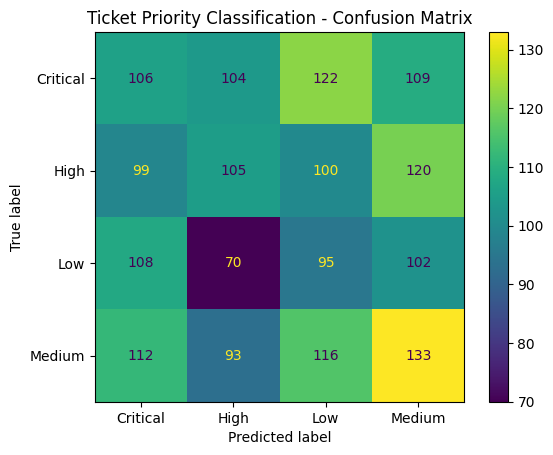

In [ ]:
# Cell 27: Confusion Matrix for Ticket Priority

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_pri_test, y_pri_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=priority_model.classes_
)

disp.plot()
plt.title("Ticket Priority Classification - Confusion Matrix")
plt.show()

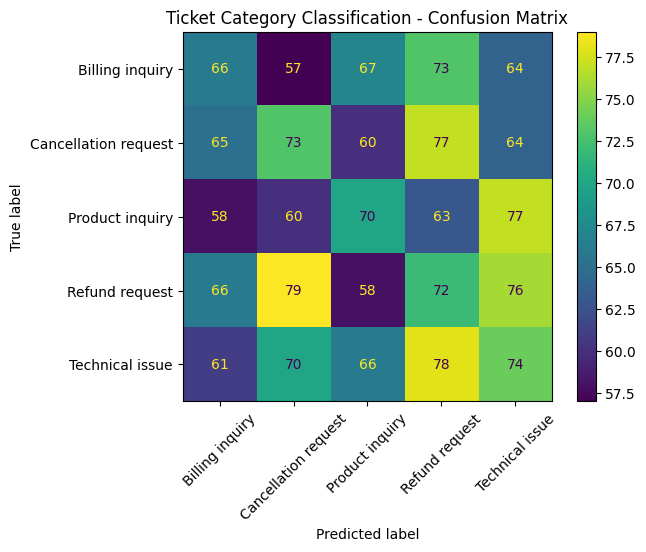

In [ ]:
# Cell 28: Confusion Matrix for Ticket Category

cm_category = confusion_matrix(y_cat_test, y_cat_pred)

disp_category = ConfusionMatrixDisplay(
    confusion_matrix=cm_category,
    display_labels=category_model.classes_
)

disp_category.plot()
plt.title("Ticket Category Classification - Confusion Matrix")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Cell 29: Model Performance Comparison

print("MODEL PERFORMANCE")
print("=" * 40)

print(f"Ticket Category Accuracy : {category_accuracy * 100:.2f}%")
print(f"Ticket Priority Accuracy : {priority_accuracy * 100:.2f}%")

print("\nBaseline Accuracy:")
print("Ticket Category: 20.00% (5 classes)")
print("Ticket Priority: 25.00% (4 classes)")

MODEL PERFORMANCE
Ticket Category Accuracy : 20.96%
Ticket Priority Accuracy : 25.91%

Baseline Accuracy:
Ticket Category: 20.00% (5 classes)
Ticket Priority: 25.00% (4 classes)


In [ ]:
# Cell: Save Ticket Category Model

import joblib

joblib.dump(category_model, "ticket_category_model.pkl")

print("Ticket Category Model saved successfully!")

Ticket Category Model saved successfully!


In [ ]:
# Cell: Save Ticket Priority Model

joblib.dump(priority_model, "ticket_priority_model.pkl")

print("Ticket Priority Model saved successfully!")

Ticket Priority Model saved successfully!


In [ ]:
# Cell: Save TF-IDF Vectorizer

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer saved successfully!")

TF-IDF Vectorizer saved successfully!


In [ ]:
# Cell 4: Verify Saved Model Files

import os

files = [
    "ticket_category_model.pkl",
    "ticket_priority_model.pkl",
    "tfidf_vectorizer.pkl"
]

print("Saved Model Files:")
for file in files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

Saved Model Files:
✓ ticket_category_model.pkl
✓ ticket_priority_model.pkl
✓ tfidf_vectorizer.pkl


In [ ]:
# Cell 5: Test Saved Models

loaded_category_model = joblib.load("ticket_category_model.pkl")
loaded_priority_model = joblib.load("ticket_priority_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

print("All models loaded successfully!")

All models loaded successfully!


In [ ]:
# Cell 6: Sample Customer Support Ticket Prediction

sample_ticket = """
I am unable to access my account.
The login page keeps showing an invalid credentials error.
Please help me recover my account.
"""

sample_vector = loaded_tfidf.transform([sample_ticket])

predicted_category = loaded_category_model.predict(sample_vector)[0]
predicted_priority = loaded_priority_model.predict(sample_vector)[0]

print("Sample Customer Support Ticket:")
print(sample_ticket)

print("\nPredicted Ticket Category:", predicted_category)
print("Predicted Ticket Priority:", predicted_priority)

Sample Customer Support Ticket:

I am unable to access my account.
The login page keeps showing an invalid credentials error.
Please help me recover my account.


Predicted Ticket Category: Refund request
Predicted Ticket Priority: Low


In [ ]:
# Cell 7: Generate Final Predictions

results = pd.DataFrame({
    "Ticket ID": df.loc[y_pri_test.index, "Ticket ID"].values,
    "Actual Category": y_cat_test.values,
    "Predicted Category": y_cat_pred,
    "Actual Priority": y_pri_test.values,
    "Predicted Priority": y_pri_pred
})

print("Prediction results created successfully!")
display(results.head(10))

Prediction results created successfully!


,Ticket ID,Actual Category,Predicted Category,Actual Priority,Predicted Priority
0,6511,Product inquiry,Cancellation request,Low,Low
1,4922,Refund request,Cancellation request,Critical,Critical
2,872,Billing inquiry,Cancellation request,Low,Critical
3,6087,Product inquiry,Billing inquiry,Medium,Critical
4,3306,Refund request,Cancellation request,Critical,Low
5,7740,Cancellation request,Technical issue,High,Medium
6,6340,Technical issue,Cancellation request,Critical,Critical
7,7812,Technical issue,Refund request,High,High
8,6845,Refund request,Billing inquiry,Low,Critical
9,564,Billing inquiry,Cancellation request,Low,Medium


In [ ]:
# Cell 8: Save Prediction Results

results.to_csv(
    "Customer_Support_Ticket_Predictions.csv",
    index=False
)

print("Prediction file saved successfully!")
print("File: Customer_Support_Ticket_Predictions.csv")
print("Shape:", results.shape)

Prediction file saved successfully!
File: Customer_Support_Ticket_Predictions.csv
Shape: (1694, 5)


In [ ]:
# Cell 9: Final Project Results

print("=" * 50)
print("CUSTOMER SUPPORT TICKET CLASSIFICATION")
print("=" * 50)

print(f"\nDataset Size: {len(df)} tickets")

print(f"\nCategory Accuracy: {category_accuracy * 100:.2f}%")
print(f"Priority Accuracy: {priority_accuracy * 100:.2f}%")

print("\nGenerated Files:")
print("✓ ticket_category_model.pkl")
print("✓ ticket_priority_model.pkl")
print("✓ tfidf_vectorizer.pkl")
print("✓ Customer_Support_Ticket_Predictions.csv")

CUSTOMER SUPPORT TICKET CLASSIFICATION

Dataset Size: 8469 tickets

Category Accuracy: 20.96%
Priority Accuracy: 25.91%

Generated Files:
✓ ticket_category_model.pkl
✓ ticket_priority_model.pkl
✓ tfidf_vectorizer.pkl
✓ Customer_Support_Ticket_Predictions.csv


In [ ]:
# Cell 10: Check Generated Files

import os

print("Project Files:")
print("=" * 40)

for file in os.listdir():
    if file.endswith((".pkl", ".csv", ".ipynb")):
        print("✓", file)

Project Files:
✓ ticket_category_model.pkl
✓ Customer_Support_Ticket_Predictions.csv
✓ ticket_priority_model.pkl
✓ customer_support_tickets.csv
✓ tfidf_vectorizer.pkl


In [ ]:
# Cell 11: Verify Prediction File

prediction_file = "Customer_Support_Ticket_Predictions.csv"

if os.path.exists(prediction_file):
    prediction_df = pd.read_csv(prediction_file)

    print("Prediction file found successfully!")
    print("Shape:", prediction_df.shape)
    print("\nColumns:")
    print(prediction_df.columns.tolist())

    display(prediction_df.head())
else:
    print("Prediction file not found!")

Prediction file found successfully!
Shape: (1694, 5)

Columns:
['Ticket ID', 'Actual Category', 'Predicted Category', 'Actual Priority', 'Predicted Priority']


,Ticket ID,Actual Category,Predicted Category,Actual Priority,Predicted Priority
0,6511,Product inquiry,Cancellation request,Low,Low
1,4922,Refund request,Cancellation request,Critical,Critical
2,872,Billing inquiry,Cancellation request,Low,Critical
3,6087,Product inquiry,Billing inquiry,Medium,Critical
4,3306,Refund request,Cancellation request,Critical,Low


In [ ]:
# Cell 12: Project Summary

print("=" * 60)
print("CUSTOMER SUPPORT TICKET CLASSIFICATION - FINAL SUMMARY")
print("=" * 60)

print("\nDataset:")
print(f"Total Tickets: {len(df)}")

print("\nModels:")
print("1. TF-IDF + Logistic Regression → Ticket Category")
print("2. TF-IDF + Logistic Regression → Ticket Priority")

print("\nPerformance:")
print(f"Category Accuracy: {category_accuracy * 100:.2f}%")
print(f"Priority Accuracy: {priority_accuracy * 100:.2f}%")

print("\nSaved Files:")
print("✓ ticket_category_model.pkl")
print("✓ ticket_priority_model.pkl")
print("✓ tfidf_vectorizer.pkl")
print("✓ Customer_Support_Ticket_Predictions.csv")

print("\nProject completed successfully!")

CUSTOMER SUPPORT TICKET CLASSIFICATION - FINAL SUMMARY

Dataset:
Total Tickets: 8469

Models:
1. TF-IDF + Logistic Regression → Ticket Category
2. TF-IDF + Logistic Regression → Ticket Priority

Performance:
Category Accuracy: 20.96%
Priority Accuracy: 25.91%

Saved Files:
✓ ticket_category_model.pkl
✓ ticket_priority_model.pkl
✓ tfidf_vectorizer.pkl
✓ Customer_Support_Ticket_Predictions.csv

Project completed successfully!


In [ ]:
# Cell 3: View First 5 Rows

display(df.head())

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [ ]:
# Cell 2: Check files available in Colab

import os

print("Files and folders:")
print(os.listdir())

Files and folders:
['.config', 'sample_data']


In [ ]:
# Check uploaded files

import os

print(os.listdir())

['.config', 'customer_support_tickets.csv', 'sample_data']
